# Macro Framework Workflow Example

This notebook is designed to live inside the `macro-framework` repo and demonstrate how to use the actual package code.

It assumes a repo structure similar to:

```text
macro-framework/
├── src/
│   ├── regression.py
│   ├── backtest.py
├── notebooks/
│   ├── 01_macro_framework_workflow.ipynb
```

This example uses **fake data** but imports the real framework functions from `src`.


## Notes

This notebook is meant to be the **package usage example** for the repo.

## 1. Imports and repo path setup

In [67]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

np.random.seed(42)
pd.set_option("display.max_columns", 50)

# Make sure the repo root is on the Python path when running from notebooks/
repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

print("Repo root added to sys.path:", repo_root)


Repo root added to sys.path: /Users


In [68]:
import sys
from pathlib import Path

repo_root = Path("/Users/lollo/macro-framework")

if str(repo_root) not in sys.path:
    sys.path.append(str(repo_root))

print("repo_root:", repo_root)
print("contains:", [p.name for p in repo_root.iterdir()])

repo_root: /Users/lollo/macro-framework
contains: ['test_driver_attribution.py', 'test_signal_diagnostic.py', 'requirements.txt', '.pytest_cache', 'Untitled.ipynb', 'test.py', 'test_model_search.py', 'README.md', 'test_backtest.py', '.gitignore', '.venv', 'test_full.py', '.ipynb_checkpoints', '.git', 'data', 'outputs', 'notebooks', 'test_regression.py', 'src']


## 2. Import functions from the framework

In [138]:
from src.regression import (
    run_ols,
    build_regression_output,
    summarize_latest,
    rolling_zscore,
    compute_fair_value_deviation,
    plot_actual_fair_value_and_zscore,
    test_stationarity,
    granger_causality_test,
    compute_vif,
    residual_diagnostics,
    build_residual_diagnostics,
    plot_residual_diagnostics,
    search_model_specifications,
    rolling_regression,
    select_best_rolling_window,
    plot_window_selection,
    plot_rolling_coefficients,
    plot_rolling_r2,
    compute_rolling_driver_attribution,
    plot_driver_attribution,
)

from src.backtest import (
    generate_signal,
    backtest_signal,
    extract_trade_log,
    compute_performance_metrics,
    compute_yearly_breakdown,
    plot_backtest,
    optimize_zscore_thresholds,
    plot_pnl_and_risk,
    build_signal_diagnostics_dataset,
    compute_signal_bucket_summary,
    compute_signal_bucket_summary_by_side,
    plot_signal_bucket_summary,

)

## 3. Generate fake macro-style dataset

We simulate:
- a target market series (`asset`)
- three explanatory macro factors (`x1`, `x2`, `x3`)

The point is not realism, but a clean and repeatable workflow example.


In [70]:
dates = pd.date_range(start="2022-01-03", periods=500, freq="B")

x1 = pd.Series(np.cumsum(np.random.normal(0, 0.03, len(dates))), index=dates, name="x1")
x2 = pd.Series(np.cumsum(np.random.normal(0, 0.02, len(dates))), index=dates, name="x2")
x3 = pd.Series(np.cumsum(np.random.normal(0, 0.025, len(dates))), index=dates, name="x3")

true_fv = 1.50 + 0.8 * x1 - 0.5 * x2 + 0.3 * x3
temporary_dislocation = pd.Series(
    np.random.normal(0, 0.12, len(dates)),
    index=dates,
    name="temporary_dislocation",
).rolling(5, min_periods=1).mean()

asset = (true_fv + temporary_dislocation).rename("asset")

df = pd.concat([asset, x1, x2, x3], axis=1)
df.head()


,asset,x1,x2,x3
2022-01-03,1.606558,0.014901,0.018524,0.034984
2022-01-04,1.511307,0.010753,0.056712,0.058100
2022-01-05,1.504013,0.030184,0.028741,0.059590
2022-01-06,1.535893,0.075875,0.040000,0.043417
2022-01-07,1.541499,0.068850,0.026987,0.060873


## 4. Run OLS regression

In [71]:
y = df["asset"]
X = df[["x1", "x2", "x3"]]

model = run_ols(y, X)
output = build_regression_output(model)

output["coefficients"]

const    1.489544
x1       0.765846
x2      -0.475056
x3       0.321973
dtype: float64

## 5. Inspect regression summary

In [72]:
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  asset   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     1574.
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          5.89e-253
Time:                        17:33:06   Log-Likelihood:                 794.56
No. Observations:                 500   AIC:                            -1581.
Df Residuals:                     496   BIC:                            -1564.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4895      0.008    183.722      0.0

## 6. Build fair value and deviation

In [73]:
df["fair_value"] = output["fitted_values"]
df["deviation"] = compute_fair_value_deviation(df["asset"], df["fair_value"])

df[["asset", "fair_value", "deviation"]].tail()

,asset,fair_value,deviation
2023-11-27,1.998912,1.917460,0.081452
2023-11-28,1.952763,1.893142,0.059621
2023-11-29,1.901150,1.892407,0.008743
2023-11-30,1.872615,1.885959,-0.013345
2023-12-01,1.811833,1.853518,-0.041685


## 7. Add standard rolling z-scores

In [74]:
df["deviation_z20"] = rolling_zscore(df["deviation"], window=20)
df["deviation_z60"] = rolling_zscore(df["deviation"], window=60)

df[["deviation", "deviation_z20", "deviation_z60"]].tail(10)


,deviation,deviation_z20,deviation_z60
2023-11-20,0.025866,0.899537,0.579415
2023-11-21,0.027697,0.849363,0.632199
2023-11-22,0.044355,1.097155,1.035682
2023-11-23,0.076106,1.562536,1.740788
2023-11-24,0.075388,1.387973,1.667845
2023-11-27,0.081452,1.393983,1.741093
2023-11-28,0.059621,0.880227,1.212534
2023-11-29,0.008743,-0.129768,0.077709
2023-11-30,-0.013345,-0.551552,-0.398322
2023-12-01,-0.041685,-1.028536,-1.022104


## 8. Plot actual, fair value, and z-scores

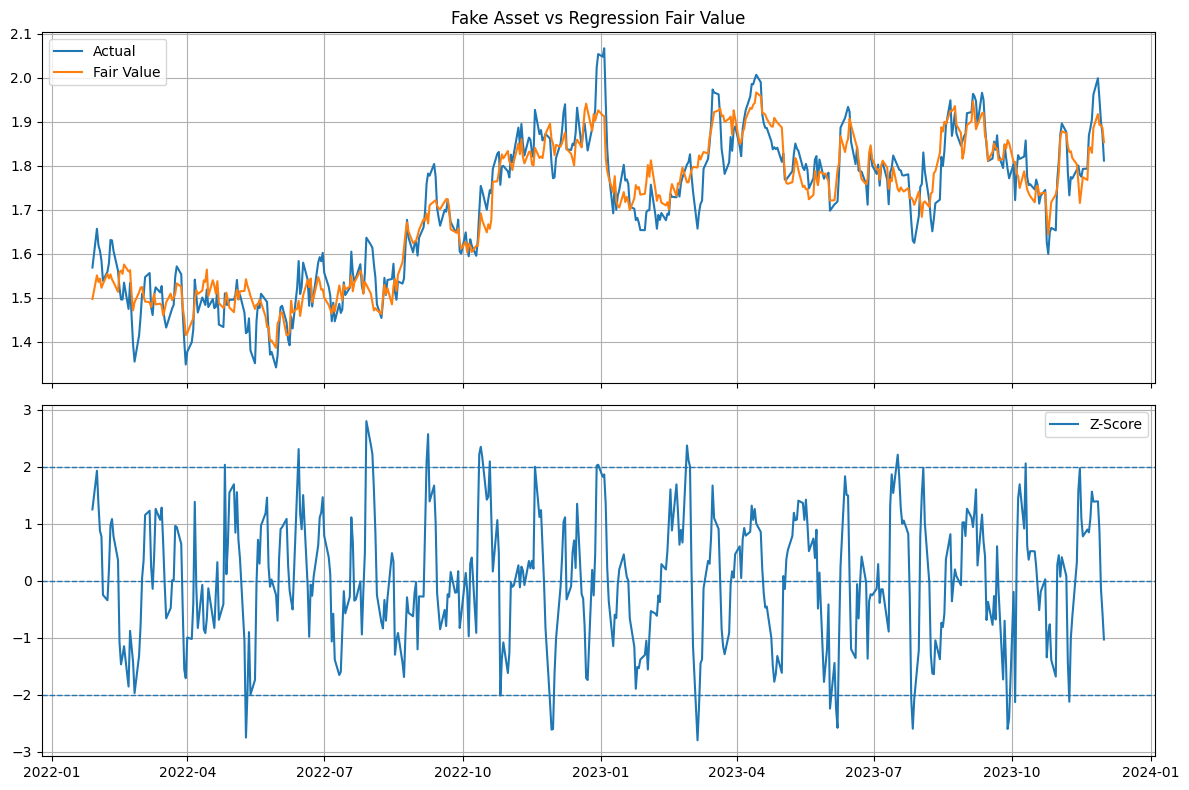

In [75]:
plot_actual_fair_value_and_zscore(
    actual=df["asset"],
    fair_value=df["fair_value"],
    zscore=df["deviation_z20"],
    title="Fake Asset vs Regression Fair Value",
)

## 9. Statistical diagnostics

Before turning a regression into a trading signal, it is useful to run a few basic statistical checks:

- stationarity of the dependent and explanatory variables
- Granger causality between drivers and the target
- multicollinearity across regressors via VIF

These checks help assess whether the chosen specification is economically and statistically sensible.

##### Stationariety Test:

In [76]:
stationarity_results = pd.DataFrame({
    "asset": test_stationarity(df["asset"]),
    "x1": test_stationarity(df["x1"]),
    "x2": test_stationarity(df["x2"]),
    "x3": test_stationarity(df["x3"]),
    "deviation": test_stationarity(df["deviation"]),
}).T

stationarity_results

,test_statistic,p_value,lags_used,n_obs,critical_values,is_stationary
asset,-2.002582,0.285442,5,494,"{'1%': -3.4436568932270095, '5%': -2.867408491...",False
x1,-1.49863,0.534189,0,499,"{'1%': -3.4435228622952065, '5%': -2.867349510...",False
x2,-0.282015,0.928013,0,499,"{'1%': -3.4435228622952065, '5%': -2.867349510...",False
x3,-0.919979,0.781322,0,499,"{'1%': -3.4435228622952065, '5%': -2.867349510...",False
deviation,-4.856893,0.000042,15,484,"{'1%': -3.4439333076538854, '5%': -2.867530121...",True


###### In fair value frameworks, the most relevant object is often not whether each raw input is stationary in isolation, but whether the regression residual / deviation is stationary. A stationary deviation is more consistent with a mean-reversion trading interpretation.

#### Granger Causality

In [77]:
granger_results = granger_causality_test(
    y=df["asset"],
    X=df[["x1", "x2", "x3"]],
    maxlag=5,
)

granger_results

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


,variable,lag,p_value,is_significant
0,x1,1,0.019310,True
1,x1,2,0.026520,True
2,x1,3,0.071135,False
3,x1,4,0.077424,False
4,x1,5,0.247188,False
5,x2,1,0.288350,False
6,x2,2,0.304805,False
7,x2,3,0.471854,False
8,x2,4,0.294319,False
9,x2,5,0.104785,False


In [78]:
granger_summary = (
    granger_results
    .groupby("variable", as_index=False)
    .agg(
        min_p_value=("p_value", "min"),
        any_significant=("is_significant", "max"),
    )
    .sort_values("min_p_value")
)

granger_summary

,variable,min_p_value,any_significant
2,x3,0.016062,True
0,x1,0.019310,True
1,x2,0.104785,False


### VIF:

In [79]:
vif_df = compute_vif(df[["x1", "x2", "x3"]])
vif_df

,variable,vif
0,x1,1.953543
1,x2,2.177220
2,x3,1.537959


## 10. Residual diagnostics

After fitting the regression, it is useful to examine the residuals directly.

This helps assess whether the fair value relationship is statistically well-behaved:
- are residuals stationary?
- is there residual autocorrelation?
- are residuals approximately normal?
- do they exhibit signs of misspecification?

In [80]:
residual_diag = build_residual_diagnostics(model)
pd.Series(residual_diag)

mean                       -0.0
std                    0.049437
adf_p_value            0.000042
is_stationary              True
durbin_watson          0.454901
ljung_box_p_value           0.0
jarque_bera_stat       0.245331
jarque_bera_p_value    0.884559
is_normal                  True
n_obs                       500
dtype: object

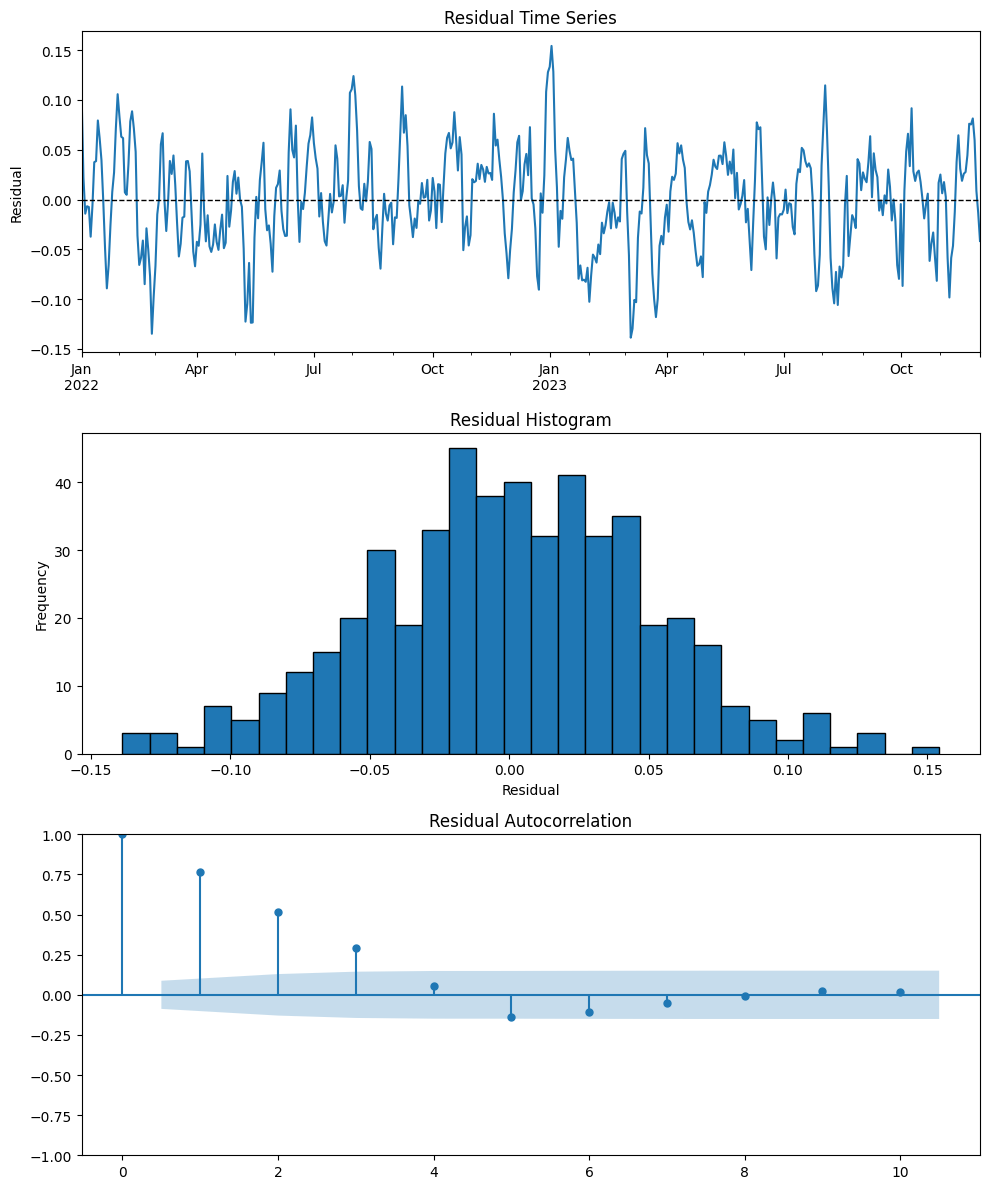

(<Figure size 1000x1200 with 3 Axes>,
 array([<Axes: title={'center': 'Residual Time Series'}, ylabel='Residual'>,
        <Axes: title={'center': 'Residual Histogram'}, xlabel='Residual', ylabel='Frequency'>,
        <Axes: title={'center': 'Residual Autocorrelation'}>], dtype=object))

In [81]:
plot_residual_diagnostics(model.resid, lags=10)

##### For fair value trading applications, residual stationarity is particularly important because it supports a mean-reversion interpretation of rich/cheap deviations. Residual autocorrelation or strong non-normality do not automatically invalidate the model, but they can indicate that the specification may be incomplete or that signal dynamics require more care.

## 11. Model specification search

A useful next step is to compare alternative model specifications rather than relying on a single chosen regression.

The function below evaluates combinations of regressors and ranks them using adjusted R², while also reporting:
- information criteria
- VIF-based multicollinearity measures
- residual stationarity diagnostics

This helps identify specifications that are both statistically strong and more robust for fair value work.

In [82]:
spec_results = search_model_specifications(
    y=df["asset"],
    X=df[["x1", "x2", "x3"]],
    min_features=1,
    max_features=3,
    top_n=10,
)

spec_results

,rank,regressors,n_regressors,r_squared,adj_r_squared,aic,bic,max_vif,avg_vif,residual_adf_p_value,residual_is_stationary
0,1,"(x1, x2, x3)",3,0.904942,0.904367,-1581.119992,-1564.261560,2.177220,1.889574,0.000042,True
1,2,"(x1, x2)",2,0.739785,0.738738,-1079.610066,-1066.966242,1.889521,1.889521,0.082621,False
2,3,"(x1, x3)",2,0.692720,0.691483,-996.484198,-983.840373,1.334732,1.334732,0.188650,False
3,4,"(x1,)",1,0.626938,0.626189,-901.491740,-893.062524,1.000000,1.000000,0.137523,False
4,5,"(x2, x3)",2,0.387103,0.384637,-651.265606,-638.621782,1.487557,1.487557,0.071755,False
5,6,"(x3,)",1,0.382568,0.381328,-649.579246,-641.150030,1.000000,1.000000,0.077137,False
6,7,"(x2,)",1,0.089333,0.087504,-455.275361,-446.846144,1.000000,1.000000,0.154618,False


#### We select the best specification:

In [83]:
best_regressors = list(spec_results.iloc[0]["regressors"])
best_regressors

['x1', 'x2', 'x3']

#### We run the best model

In [84]:
best_model = run_ols(df["asset"], df[best_regressors])
best_output = build_regression_output(best_model)

print(best_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  asset   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.904
Method:                 Least Squares   F-statistic:                     1574.
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          5.89e-253
Time:                        17:33:07   Log-Likelihood:                 794.56
No. Observations:                 500   AIC:                            -1581.
Df Residuals:                     496   BIC:                            -1564.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4895      0.008    183.722      0.0

#### In sample fair value from best specification:

In [85]:
df["best_fair_value"] = best_output["fitted_values"]
df["best_deviation"] = compute_fair_value_deviation(df["asset"], df["best_fair_value"])
df["best_deviation_z20"] = rolling_zscore(df["best_deviation"], window=20)

df[["asset", "best_fair_value", "best_deviation", "best_deviation_z20"]].tail()

,asset,best_fair_value,best_deviation,best_deviation_z20
2023-11-27,1.998912,1.917460,0.081452,1.393983
2023-11-28,1.952763,1.893142,0.059621,0.880227
2023-11-29,1.901150,1.892407,0.008743,-0.129768
2023-11-30,1.872615,1.885959,-0.013345,-0.551552
2023-12-01,1.811833,1.853518,-0.041685,-1.028536


#### Plotting:

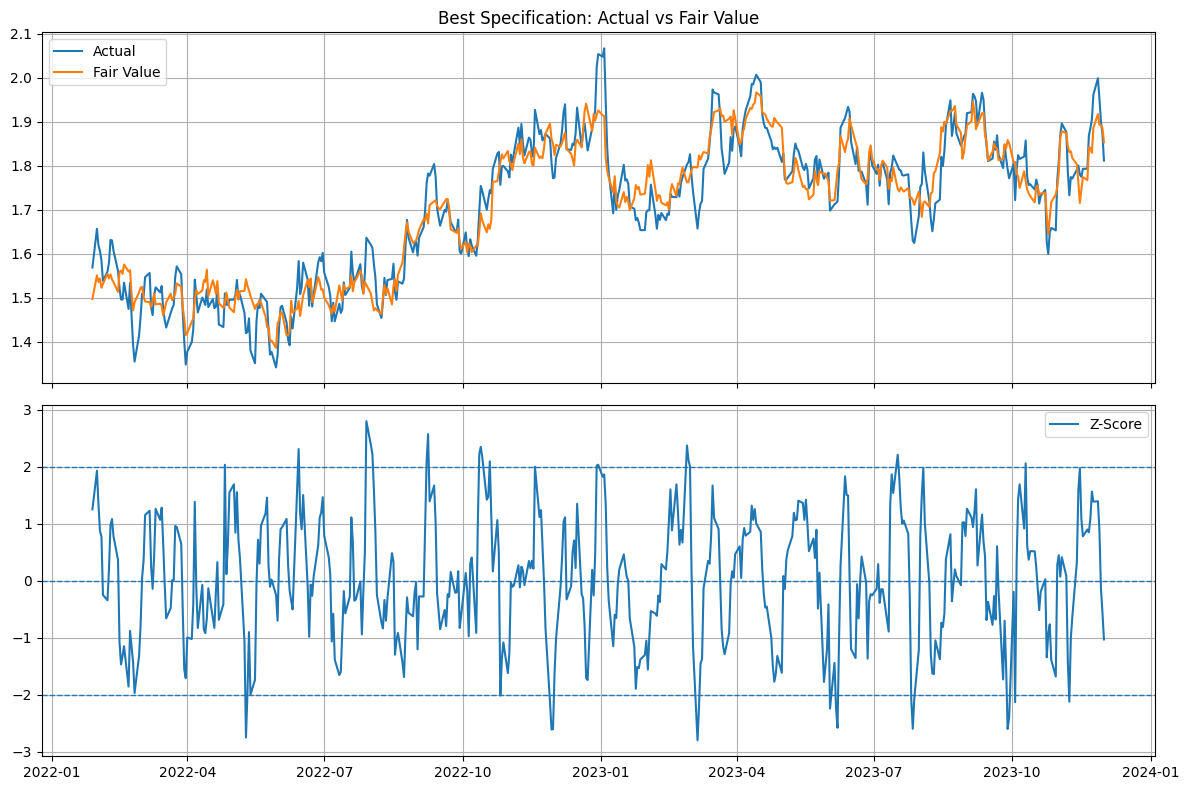

In [86]:
plot_actual_fair_value_and_zscore(
    actual=df["asset"],
    fair_value=df["best_fair_value"],
    zscore=df["best_deviation_z20"],
    title="Best Specification: Actual vs Fair Value",
)

## 12. Rolling regression

A full-sample regression can hide instability over time. Rolling regression helps assess whether the relationship between the asset and its drivers is stable or changing across subsamples.

This is useful in macro trading because:
- coefficients may drift across regimes
- explanatory power may weaken or strengthen over time
- fair value relationships may not be constant

In [87]:
rolling_output = rolling_regression(
    y=df["asset"],
    X=df[["x1", "x2", "x3"]],
    window=60,
)

rolling_output.keys()

dict_keys(['rolling_coefficients', 'rolling_r2', 'rolling_fitted_values', 'rolling_residuals'])

In [88]:
rolling_output["rolling_coefficients"].tail()

,const,x1,x2,x3
2023-11-27,1.506675,0.817956,-0.552907,0.328139
2023-11-28,1.451507,0.851350,-0.556986,0.375201
2023-11-29,1.468660,0.827948,-0.566527,0.365886
2023-11-30,1.495908,0.785276,-0.580331,0.350932
2023-12-01,1.528671,0.780556,-0.569829,0.318174


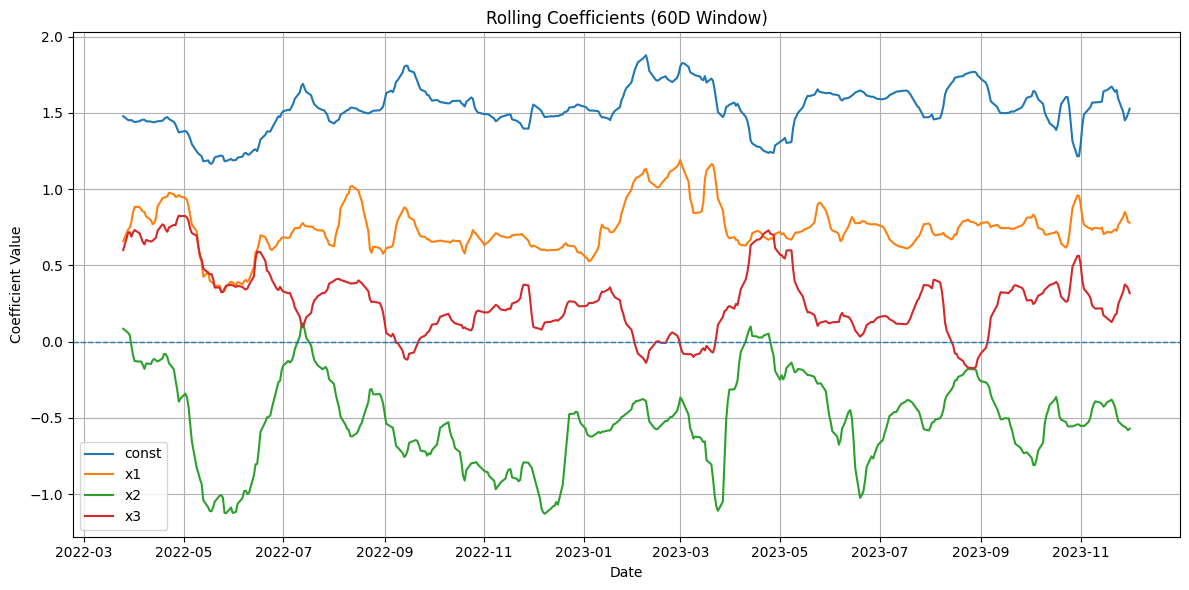

,const,x1,x2,x3
2022-03-25,1.478870,0.659034,0.084907,0.601321
2022-03-28,1.453367,0.735721,0.058529,0.714518
2022-03-29,1.451546,0.749794,0.042335,0.718397
2022-03-30,1.454007,0.785073,-0.026924,0.688927
2022-03-31,1.445447,0.848085,-0.087804,0.717227
...,...,...,...,...
2023-11-27,1.506675,0.817956,-0.552907,0.328139
2023-11-28,1.451507,0.851350,-0.556986,0.375201
2023-11-29,1.468660,0.827948,-0.566527,0.365886
2023-11-30,1.495908,0.785276,-0.580331,0.350932


In [89]:
plot_rolling_coefficients(
    rolling_output["rolling_coefficients"],
    title="Rolling Coefficients (60D Window)",
)

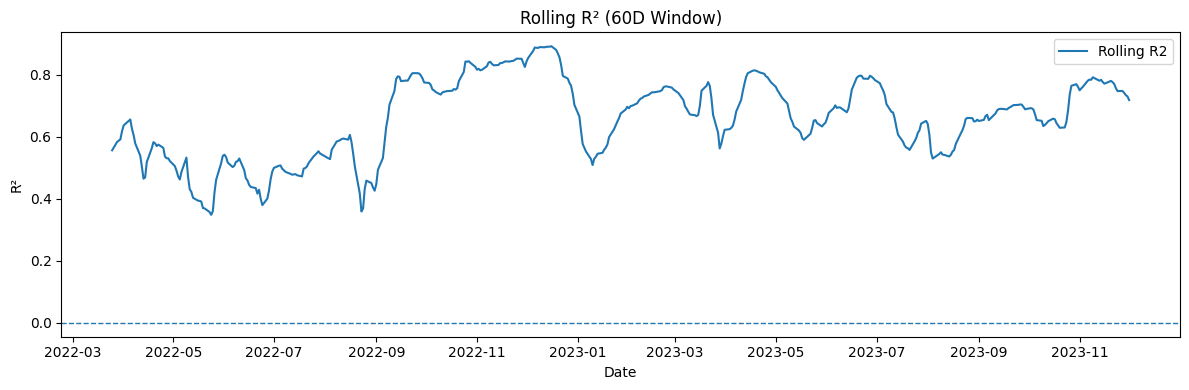

2022-01-03         NaN
2022-01-04         NaN
2022-01-05         NaN
2022-01-06         NaN
2022-01-07         NaN
                ...   
2023-11-27    0.747411
2023-11-28    0.741129
2023-11-29    0.733796
2023-11-30    0.729776
2023-12-01    0.718043
Freq: B, Length: 500, dtype: float64

In [90]:
plot_rolling_r2(
    rolling_output["rolling_r2"],
    title="Rolling R² (60D Window)",
)

In [91]:
df["rolling_fair_value_60"] = rolling_output["rolling_fitted_values"]
df["rolling_residual_60"] = rolling_output["rolling_residuals"]
df["rolling_residual_z20"] = rolling_zscore(df["rolling_residual_60"], window=20)

df[["asset", "rolling_fair_value_60", "rolling_residual_60", "rolling_residual_z20"]].tail()

,asset,rolling_fair_value_60,rolling_residual_60,rolling_residual_z20
2023-11-27,1.998912,1.932016,0.066896,1.098193
2023-11-28,1.952763,1.913555,0.039208,0.449682
2023-11-29,1.901150,1.910765,-0.009615,-0.606023
2023-11-30,1.872615,1.901664,-0.029049,-0.984055
2023-12-01,1.811833,1.858841,-0.047008,-1.249218


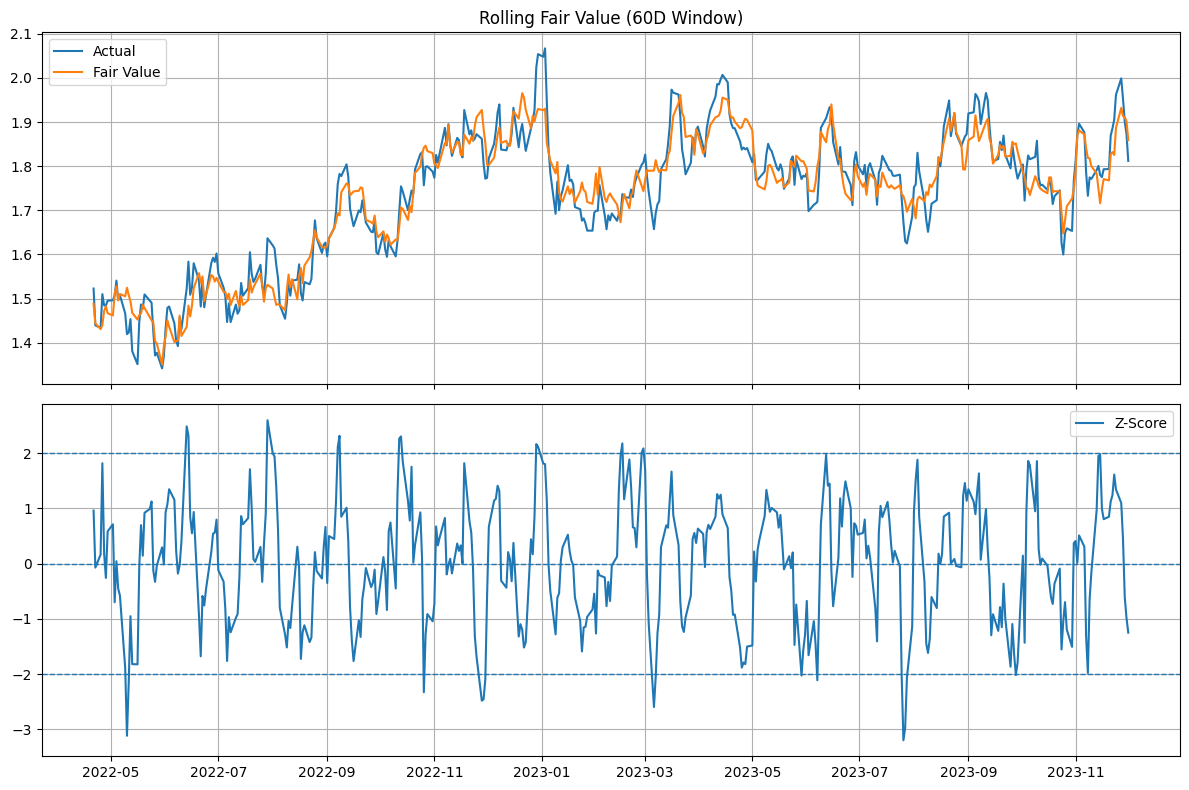

In [92]:
plot_actual_fair_value_and_zscore(
    actual=df["asset"],
    fair_value=df["rolling_fair_value_60"],
    zscore=df["rolling_residual_z20"],
    title="Rolling Fair Value (60D Window)",
)

## 13. Rolling window selection

Rolling results depend on the chosen lookback window. A shorter window can adapt faster but may be noisier; a longer window can be more stable but slower to capture regime shifts.

The function below compares candidate rolling windows and ranks them using either:
- SSR
- RMSE

This helps identify a more robust rolling specification.

In [93]:
window_selection = select_best_rolling_window(
    y=df["asset"],
    X=df[["x1", "x2", "x3"]],
    windows=[20, 40, 60, 90, 120],
    criterion="rmse",
)

window_selection["best_window"], window_selection["best_score"]

(20, 0.03772258026950381)

In [94]:
window_selection["comparison"]

,window,ssr,rmse,n_obs
0,20,0.684460,0.037723,481
1,40,0.909093,0.044407,461
2,60,0.898328,0.045133,441
3,120,0.816726,0.046299,381
4,90,0.898814,0.046764,411


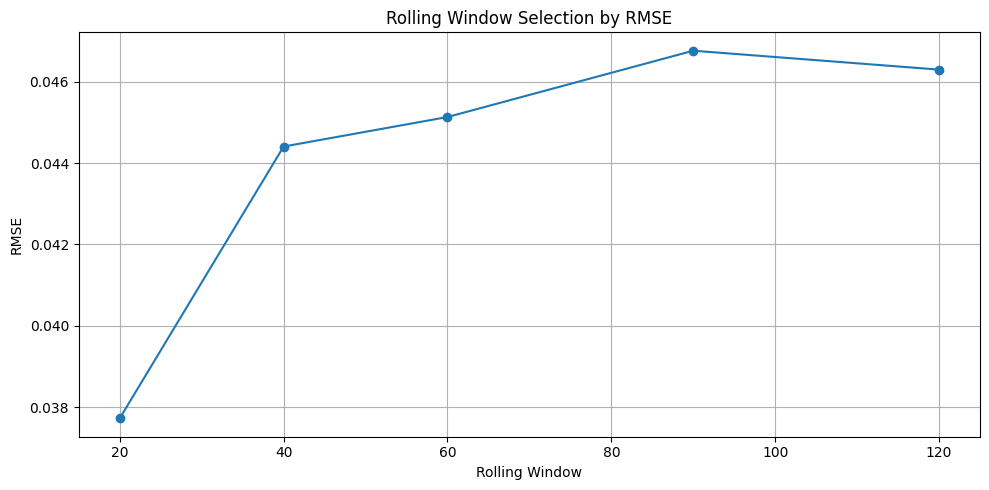

In [95]:
plot_window_selection(
    window_selection["comparison"],
    criterion="rmse",
    title="Rolling Window Selection by RMSE",
)

### We now use the best window:

In [96]:
best_window = window_selection["best_window"]
best_rolling_output = window_selection["best_output"]

print("Best rolling window:", best_window)

Best rolling window: 20


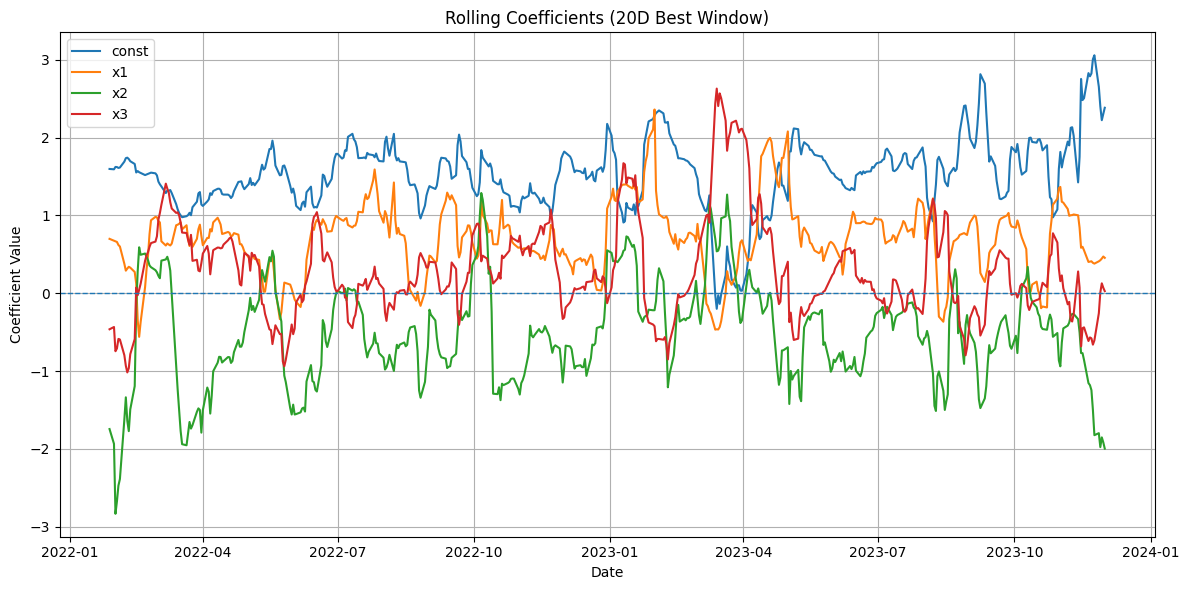

,const,x1,x2,x3
2022-01-28,1.598013,0.699725,-1.744542,-0.462301
2022-01-31,1.593437,0.675986,-1.934196,-0.433209
2022-02-01,1.623884,0.667089,-2.833543,-0.744378
2022-02-02,1.622379,0.659943,-2.673187,-0.708216
2022-02-03,1.611023,0.620924,-2.471159,-0.585746
...,...,...,...,...
2023-11-27,2.653663,0.410977,-1.797501,-0.256596
2023-11-28,2.403008,0.425183,-1.976094,0.010985
2023-11-29,2.224453,0.446403,-1.851506,0.128090
2023-11-30,2.306774,0.472773,-1.914693,0.071529


In [97]:
plot_rolling_coefficients(
    best_rolling_output["rolling_coefficients"],
    title=f"Rolling Coefficients ({best_window}D Best Window)",
)

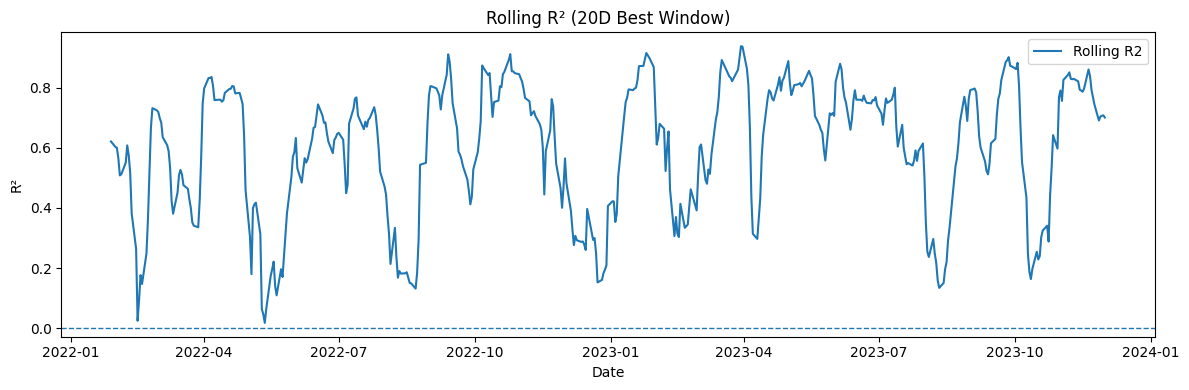

2022-01-03         NaN
2022-01-04         NaN
2022-01-05         NaN
2022-01-06         NaN
2022-01-07         NaN
                ...   
2023-11-27    0.691102
2023-11-28    0.704170
2023-11-29    0.706754
2023-11-30    0.708125
2023-12-01    0.701115
Freq: B, Length: 500, dtype: float64

In [98]:
plot_rolling_r2(
    best_rolling_output["rolling_r2"],
    title=f"Rolling R² ({best_window}D Best Window)",
)

In [99]:
df[f"rolling_fair_value_{best_window}"] = best_rolling_output["rolling_fitted_values"]
df[f"rolling_residual_{best_window}"] = best_rolling_output["rolling_residuals"]
df[f"rolling_residual_z20_{best_window}"] = rolling_zscore(
    df[f"rolling_residual_{best_window}"],
    window=20,
)

df[
    [
        "asset",
        f"rolling_fair_value_{best_window}",
        f"rolling_residual_{best_window}",
        f"rolling_residual_z20_{best_window}",
    ]
].tail()

,asset,rolling_fair_value_20,rolling_residual_20,rolling_residual_z20_20
2023-11-27,1.998912,1.937825,0.061087,1.511369
2023-11-28,1.952763,1.888442,0.064320,1.425733
2023-11-29,1.901150,1.879795,0.021355,0.329399
2023-11-30,1.872615,1.883370,-0.010755,-0.545263
2023-12-01,1.811833,1.833847,-0.022014,-0.865680


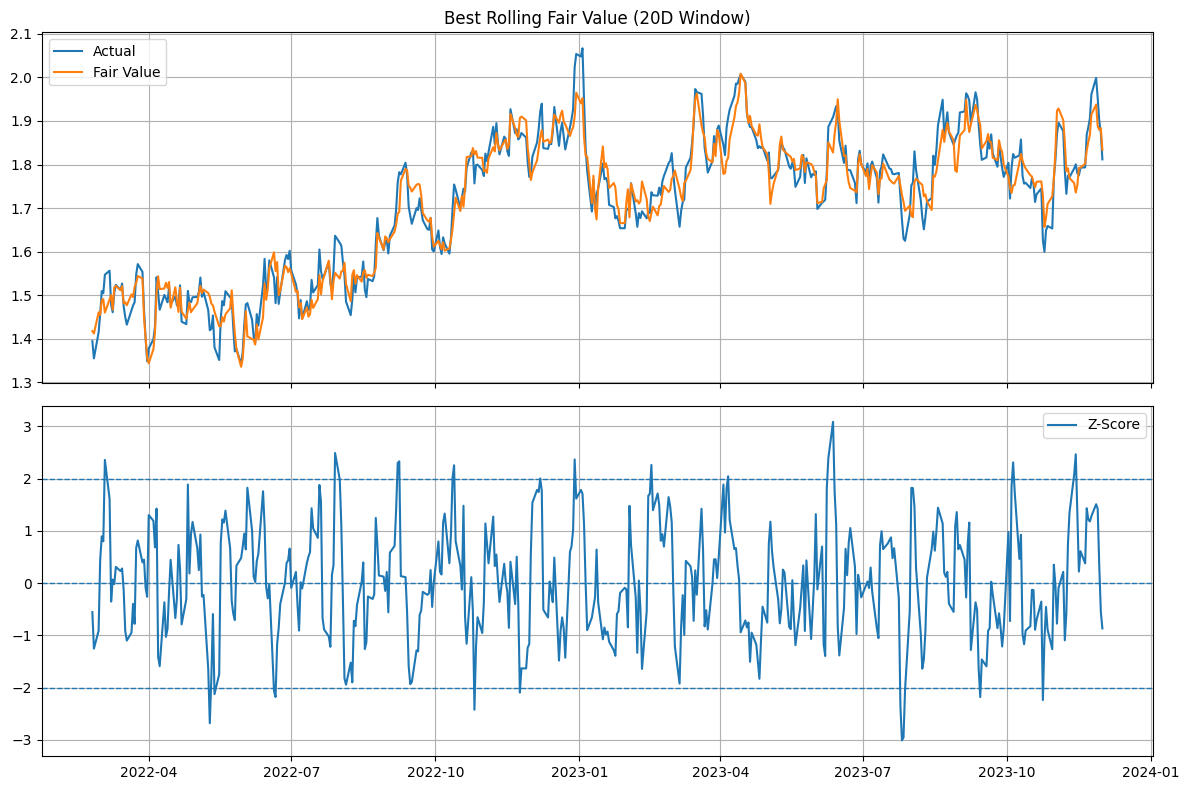

In [100]:
plot_actual_fair_value_and_zscore(
    actual=df["asset"],
    fair_value=df[f"rolling_fair_value_{best_window}"],
    zscore=df[f"rolling_residual_z20_{best_window}"],
    title=f"Best Rolling Fair Value ({best_window}D Window)",
)

## 14. Driver contribution over time

Beyond estimating fair value, it is useful to understand which drivers are contributing to the model's explanatory power over time.

Using a rolling framework, we compute marginal contributions of each regressor based on the change in R² when the variable is removed from the model.

This provides a dynamic view of which factors are driving the relationship at different points in time.

In [101]:
driver_output = compute_rolling_driver_attribution(
    y=df["asset"],
    X=df[["x1", "x2", "x3"]],
    window=60,
)

driver_output.keys()

dict_keys(['rolling_r2', 'raw_contributions', 'normalized_contributions'])

In [102]:
driver_output["raw_contributions"].tail()

,x1,x2,x3
2023-11-27,0.213561,0.092184,0.036715
2023-11-28,0.238187,0.093081,0.058279
2023-11-29,0.232699,0.097289,0.069805
2023-11-30,0.214415,0.104765,0.077302
2023-12-01,0.205825,0.102383,0.071806


In [103]:
driver_output["normalized_contributions"].tail()

,x1,x2,x3
2023-11-27,0.623609,0.269181,0.107210
2023-11-28,0.611445,0.238947,0.149608
2023-11-29,0.582049,0.243348,0.174603
2023-11-30,0.540793,0.264238,0.194969
2023-12-01,0.541625,0.269419,0.188956


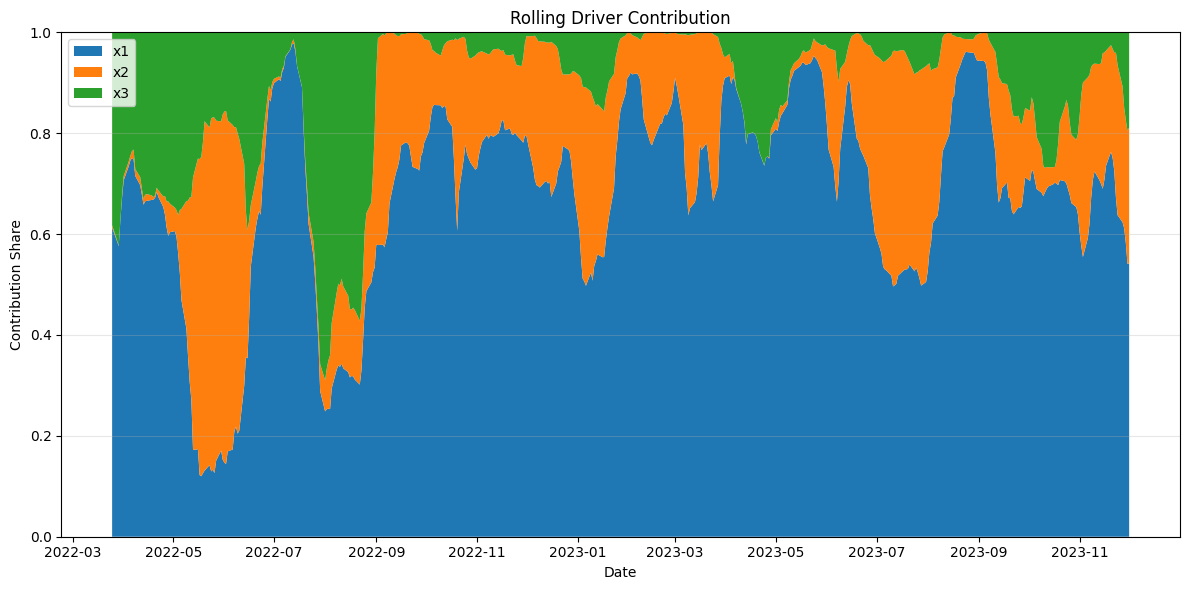

,x1,x2,x3
2022-01-03,NaN,NaN,NaN
2022-01-04,NaN,NaN,NaN
2022-01-05,NaN,NaN,NaN
2022-01-06,NaN,NaN,NaN
2022-01-07,NaN,NaN,NaN
...,...,...,...
2023-11-27,0.623609,0.269181,0.107210
2023-11-28,0.611445,0.238947,0.149608
2023-11-29,0.582049,0.243348,0.174603
2023-11-30,0.540793,0.264238,0.194969


In [104]:
plot_driver_attribution(
    driver_output["normalized_contributions"],
    title="Rolling Driver Contribution",
)

Driver contributions are computed as marginal changes in R² and are therefore sensitive to multicollinearity. Contributions should be interpreted as indicative rather than strictly causal.

In a macro context, this is particularly useful to identify regime shifts where different drivers become dominant over time.

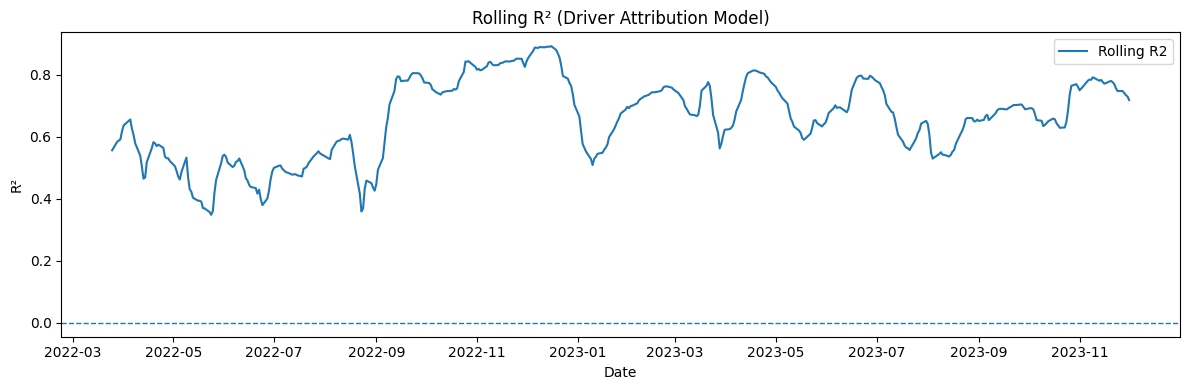

2022-01-03         NaN
2022-01-04         NaN
2022-01-05         NaN
2022-01-06         NaN
2022-01-07         NaN
                ...   
2023-11-27    0.747411
2023-11-28    0.741129
2023-11-29    0.733796
2023-11-30    0.729776
2023-12-01    0.718043
Freq: B, Length: 500, dtype: float64

In [105]:
plot_rolling_r2(
    driver_output["rolling_r2"],
    title="Rolling R² (Driver Attribution Model)",
)

## 15. Threshold optimization on the best rolling model

We now move from model construction to signal design.

The input signal is the z-score of the residual from the best rolling regression window.  
We test a range of entry thresholds and compare performance in order to identify a reasonable trading rule before running the full backtest.

In [115]:
df["best_rolling_fair_value"] = best_rolling_output["rolling_fitted_values"]
df["best_rolling_residual"] = best_rolling_output["rolling_residuals"]
df["best_rolling_residual_z20"] = rolling_zscore(df["best_rolling_residual"], window=20)

df[["asset", "best_rolling_fair_value", "best_rolling_residual", "best_rolling_residual_z20"]].tail()

,asset,best_rolling_fair_value,best_rolling_residual,best_rolling_residual_z20
2023-11-27,1.998912,1.937825,0.061087,1.511369
2023-11-28,1.952763,1.888442,0.064320,1.425733
2023-11-29,1.901150,1.879795,0.021355,0.329399
2023-11-30,1.872615,1.883370,-0.010755,-0.545263
2023-12-01,1.811833,1.833847,-0.022014,-0.865680


In [117]:
threshold_results = optimize_zscore_thresholds(
    price=df["asset"],
    zscore=-df["best_rolling_residual_z20"],
    thresholds=[0.5, 1.0, 1.5, 2.0, 2.5, 3.0],
)

threshold_results

,threshold,total_pnl_bp,sharpe,hit_ratio,trade_days
0,2.0,20.924093,0.931292,0.592593,27
1,1.5,17.387969,0.358646,0.573333,75
2,0.5,10.135998,0.100620,0.523026,304
3,2.5,5.833042,0.942401,0.750000,4
4,3.0,5.627329,0.917064,1.000000,2
5,1.0,-33.444540,-0.464011,0.490566,159


In [118]:
best_entry_threshold = float(threshold_results.iloc[0]["threshold"])
best_entry_threshold

2.0

## 16. Signal generation

Using the selected threshold, we convert the rolling residual z-score into a mean-reversion trading signal.

In [119]:
chosen_entry_threshold = best_entry_threshold
chosen_exit_threshold = 0.5

In [120]:
df["best_signal"] = generate_signal(
    zscore=df["best_rolling_residual_z20"],
    entry_threshold=chosen_entry_threshold,
    exit_threshold=chosen_exit_threshold,
)

df[["best_rolling_residual", "best_rolling_residual_z20", "best_signal"]].tail(30)

,best_rolling_residual,best_rolling_residual_z20,best_signal
2023-10-23,-0.016226,-0.353233,0
2023-10-24,-0.103553,-2.238313,-1
2023-10-25,-0.057124,-1.070594,-1
2023-10-26,-0.029621,-0.453995,0
2023-10-27,-0.050487,-0.889339,0
2023-10-30,-0.073596,-1.264238,0
2023-10-31,0.001256,0.353192,0
2023-11-01,-0.020117,-0.033425,0
2023-11-02,-0.053727,-0.775311,0
2023-11-03,-0.032585,-0.091873,0


## 17. Backtest

We backtest the signal against the asset series, using lagged positions to avoid look-ahead bias.

In [121]:
bt = backtest_signal(
    signal=df["best_signal"],
    price=df["asset"],
)

bt.tail()

,price,signal,position,price_change,daily_pnl_bp,cumulative_pnl_bp
2023-11-27,1.998912,0,0,0.037264,0.0,-23.293387
2023-11-28,1.952763,0,0,-0.046149,-0.0,-23.293387
2023-11-29,1.901150,0,0,-0.051613,-0.0,-23.293387
2023-11-30,1.872615,0,0,-0.028535,-0.0,-23.293387
2023-12-01,1.811833,0,0,-0.060781,-0.0,-23.293387


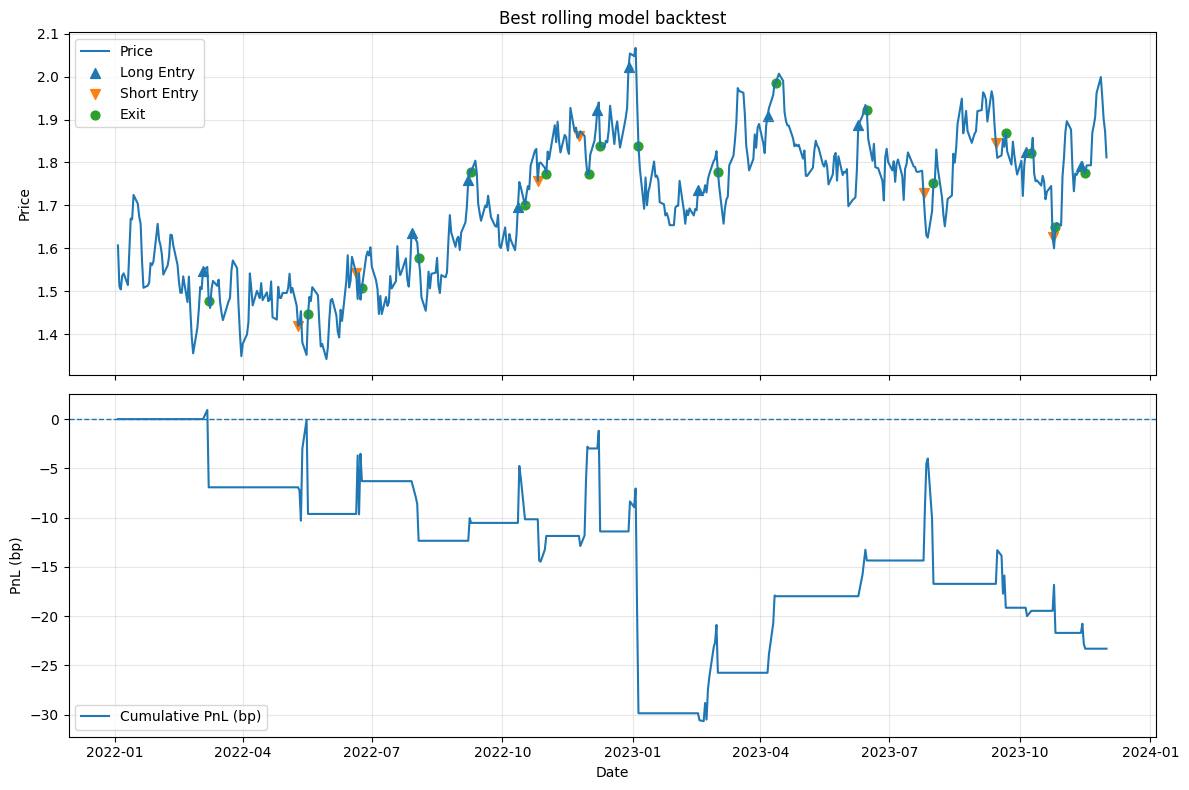

(<Figure size 1200x800 with 2 Axes>,
 array([<Axes: title={'center': 'Best rolling model backtest'}, ylabel='Price'>,
        <Axes: xlabel='Date', ylabel='PnL (bp)'>], dtype=object))

In [132]:
plot_backtest(
    bt, 
    title = "Best rolling model backtest"
)

## 18. Trade log

We extract completed trades to evaluate holding periods, directional performance, and trade-level PnL.

In [122]:
trade_log = extract_trade_log(
    backtest_df=bt,
    zscore=df["best_rolling_residual_z20"],
)

trade_log.head(10)

,entry_date,exit_date,side,signal_type,entry_price,exit_price,holding_period,pnl_bp,entry_zscore,exit_zscore
0,2022-03-04,2022-03-08,long,fade_cheapness,1.547087,1.477889,2,-6.919784,2.359947,-0.351959
1,2022-05-10,2022-05-17,short,fade_richness,1.419576,1.446592,5,-2.701665,-2.682071,0.775600
2,2022-06-20,2022-06-24,short,fade_richness,1.541166,1.507907,4,3.325837,-2.064672,-0.396869
3,2022-07-29,2022-08-03,long,fade_cheapness,1.636554,1.576065,3,-6.048831,2.491857,-0.298752
4,2022-09-07,2022-09-09,long,fade_cheapness,1.759378,1.777516,2,1.813801,2.300942,0.134400
5,2022-10-12,2022-10-17,long,fade_cheapness,1.696449,1.700124,3,0.367520,2.008039,0.334140
6,2022-10-26,2022-11-01,short,fade_richness,1.756675,1.773602,4,-1.692687,-2.423724,-0.374468
7,2022-11-24,2022-12-01,short,fade_richness,1.862260,1.773494,5,8.876648,-2.095451,0.561001
8,2022-12-07,2022-12-09,long,fade_cheapness,1.921773,1.837592,2,-8.418025,2.005482,-0.509294
9,2022-12-29,2023-01-05,long,fade_cheapness,2.023366,1.838865,5,-18.450185,2.368331,0.000708


## 19. Trade metrics:

In [123]:
metrics = compute_performance_metrics(
    backtest_df = bt,
    trade_log = trade_log,
)

metrics

{'overall': {'cumulative_pnl_bp': -23.293386503246506,
  'sharpe_ratio': -0.4859656906277617,
  'hit_ratio': 0.3888888888888889,
  'max_drawdown_bp': -31.57123830474302,
  'pnl_vol_bp': 1.5217989846276128,
  'number_of_trades': 18,
  'avg_holding_period': 3.888888888888889},
 'long': {'cumulative_pnl_bp': -24.07006058447481,
  'sharpe_ratio': -0.6918676712538046,
  'hit_ratio': 0.45454545454545453,
  'max_drawdown_bp': -39.37937095600196,
  'pnl_vol_bp': 1.1045475369595656,
  'number_of_trades': 11,
  'avg_holding_period': 3.6363636363636362},
 'short': {'cumulative_pnl_bp': 0.7766740812283004,
  'sharpe_ratio': 0.02355720904332367,
  'hit_ratio': 0.2857142857142857,
  'max_drawdown_bp': -17.380647248393764,
  'pnl_vol_bp': 1.0467554784952096,
  'number_of_trades': 7,
  'avg_holding_period': 4.285714285714286}}

In [128]:
stats_table = pd.concat(
    [
        pd.Series(metrics['overall'], name = 'overall'), 
        pd.Series(metrics['long'], name = 'long'),
        pd.Series(metrics['short'], name = 'short')
    ],
    axis = 1,
)

stats_table

,overall,long,short
cumulative_pnl_bp,-23.293387,-24.070061,0.776674
sharpe_ratio,-0.485966,-0.691868,0.023557
hit_ratio,0.388889,0.454545,0.285714
max_drawdown_bp,-31.571238,-39.379371,-17.380647
pnl_vol_bp,1.521799,1.104548,1.046755
number_of_trades,18.000000,11.000000,7.000000
avg_holding_period,3.888889,3.636364,4.285714


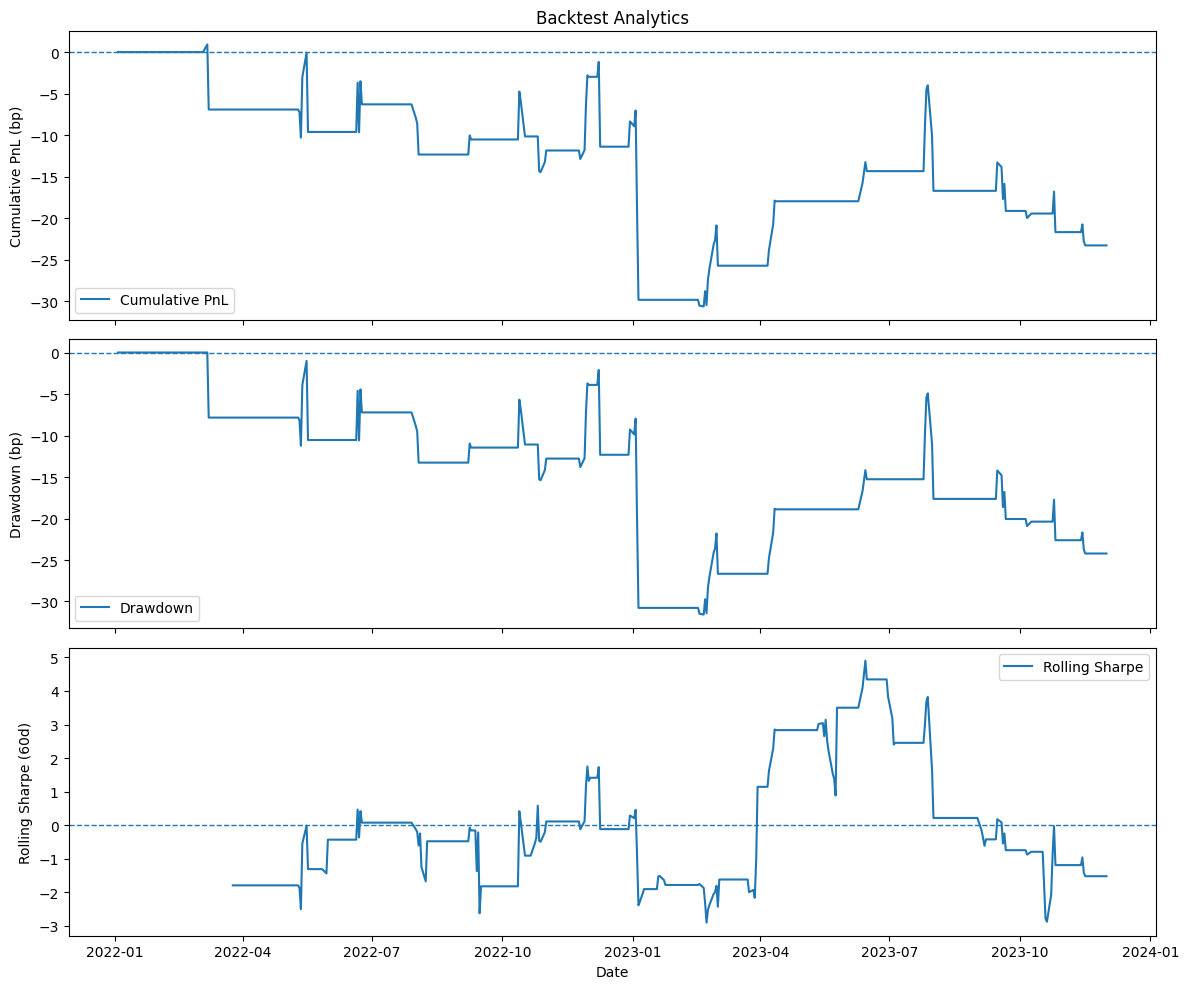

In [131]:
plot_pnl_and_risk(bt)

### Yearly breakdown

In [135]:
yearly = compute_yearly_breakdown(
    backtest_df=bt,
    trade_log=trade_log,
)

yearly

,cumulative_pnl_bp,sharpe_ratio,hit_ratio,number_of_trades
year,,,,
2022,-8.351292,-0.335259,0.444444,9
2023,-14.942094,-0.647744,0.333333,9


### PnL Decomposition

In [136]:
# TOTAL
bt["total_cum_pnl"] = bt["cumulative_pnl_bp"]

# LONG ONLY
bt["long_daily_pnl"] = bt["daily_pnl_bp"].where(
    bt["position"].shift(1).fillna(0) > 0,
    0.0,
)
bt["long_cum_pnl"] = bt["long_daily_pnl"].cumsum()

# SHORT ONLY
bt["short_daily_pnl"] = bt["daily_pnl_bp"].where(
    bt["position"].shift(1).fillna(0) < 0,
    0.0,
)
bt["short_cum_pnl"] = bt["short_daily_pnl"].cumsum()

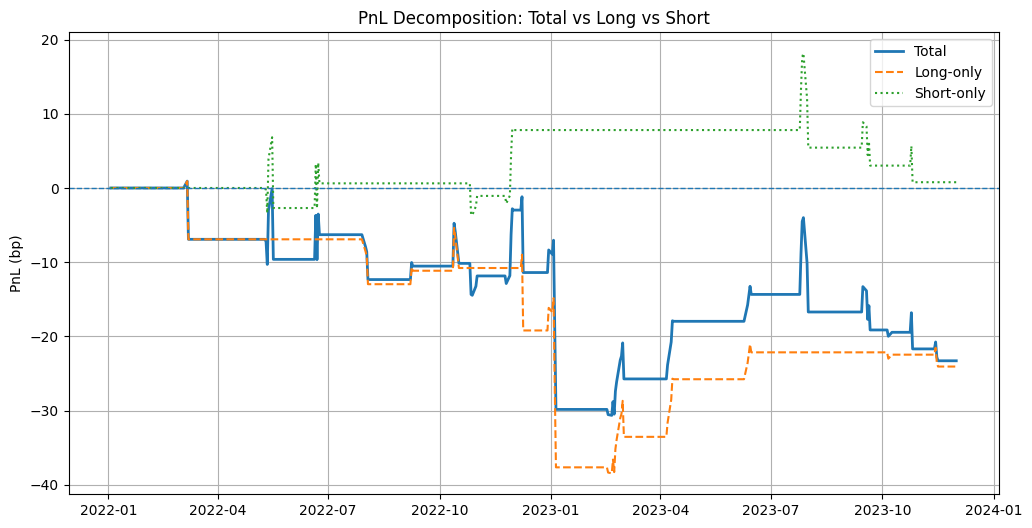

In [137]:
plt.figure(figsize=(12,6))

plt.plot(bt.index, bt["total_cum_pnl"], label="Total", linewidth=2)
plt.plot(bt.index, bt["long_cum_pnl"], label="Long-only", linestyle="--")
plt.plot(bt.index, bt["short_cum_pnl"], label="Short-only", linestyle=":")

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("PnL Decomposition: Total vs Long vs Short")
plt.ylabel("PnL (bp)")
plt.legend()
plt.grid(True)

plt.show()

The strategy performance should be evaluated across multiple dimensions:

- total return (cumulative PnL)
- risk-adjusted return (Sharpe ratio)
- downside risk (maximum drawdown)
- trade efficiency (hit ratio and average PnL)
- stability over time (yearly breakdown)

In mean-reversion strategies, it is common to observe moderate hit ratios combined with favorable average trade asymmetry.

### 21. Z-score Bucket analysis:

Signal diagnostics show how performance varies with the magnitude of the z-score.

This helps:
- identify effective entry thresholds
- detect asymmetry between long and short signals
- understand whether extreme dislocations provide stronger alpha

In many macro mean-reversion strategies, larger deviations tend to produce stronger and more reliable signals.

In [139]:
diagnostics_df = build_signal_diagnostics_dataset(
    backtest_df=bt,
    zscore=df["best_rolling_residual_z20"],
)

diagnostics_df.head()

,price,signal,position,price_change,daily_pnl_bp,cumulative_pnl_bp,total_cum_pnl,long_daily_pnl,long_cum_pnl,short_daily_pnl,short_cum_pnl,zscore,abs_zscore,signal_side,position_side,signal_type,is_active,pnl_positive
2022-01-03,1.606558,0,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,flat,flat,flat,False,False
2022-01-04,1.511307,0,0,-0.095251,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,flat,flat,flat,False,False
2022-01-05,1.504013,0,0,-0.007294,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,flat,flat,flat,False,False
2022-01-06,1.535893,0,0,0.031880,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,flat,flat,flat,False,False
2022-01-07,1.541499,0,0,0.005605,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,flat,flat,flat,False,False


In [140]:
bucket_summary = compute_signal_bucket_summary(
    diagnostics_df,
    bins=[0, 0.5, 1, 1.5, 2, 3, np.inf],
)

bucket_summary

,count,avg_pnl_bp,median_pnl_bp,total_pnl_bp,pnl_vol_bp,hit_ratio
zscore_bucket,,,,,,
"(-0.001, 0.5]",0,NaN,NaN,0.000000,NaN,NaN
"(0.5, 1.0]",13,0.272027,1.220243,3.536346,3.370442,0.538462
"(1.0, 1.5]",15,-0.219348,1.233311,-3.290224,4.440391,0.600000
"(1.5, 2.0]",15,0.720146,0.923108,10.802197,1.564858,0.533333
"(2.0, 3.0]",25,1.084470,0.000000,27.111745,2.216256,0.280000
"(3.0, inf]",2,3.845926,3.845926,7.691853,2.313341,1.000000


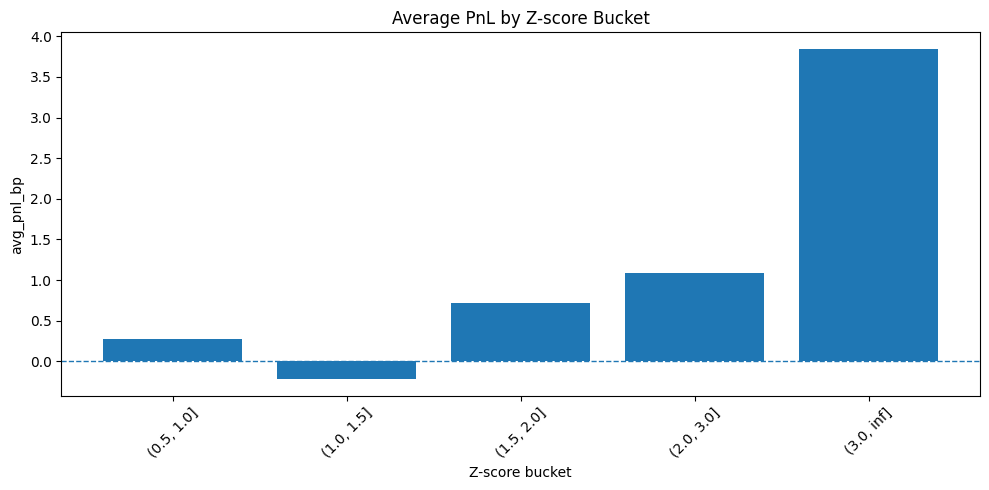

In [141]:
plot_signal_bucket_summary(
    bucket_summary,
    column="avg_pnl_bp",
    title="Average PnL by Z-score Bucket",
)

In [142]:
bucket_by_side = compute_signal_bucket_summary_by_side(
    diagnostics_df,
)

bucket_by_side

count  avg_pnl_bp  median_pnl_bp  total_pnl_bp  \
position_side zscore_bucket                                                   
long          (-0.001, 0.5]      0         NaN            NaN      0.000000   
              (0.5, 1.0]         6    1.244362       2.059046      7.466171   
              (1.0, 1.5]         9   -0.911665       0.535785     -8.204985   
              (1.5, 2.0]        10    0.871893       1.099546      8.718934   
              (2.0, 3.0]        14    0.643197       0.000000      9.004759   
              (3.0, inf]         1    2.210148       2.210148      2.210148   
short         (-0.001, 0.5]      0         NaN            NaN      0.000000   
              (0.5, 1.0]         7   -0.561404      -0.113859     -3.929826   
              (1.0, 1.5]         6    0.819127       3.030691      4.914761   
              (1.5, 2.0]         5    0.416653      -0.310425      2.083264   
              (2.0, 3.0]        11    1.646090      -0.000000     18.106986   
              (3.0, inf]         1    5.481705       5.481705      5.481705   

                             pnl_vol_bp  hit_ratio  
position_side zscore_bucket                         
long          (-0.001, 0.5]         NaN        NaN  
              (0.5, 1.0]       2.184162   0.666667  
              (1.0, 1.5]       4.395681   0.555556  
              (1.5, 2.0]       1.611875   0.600000  
              (2.0, 3.0]       1.610204   0.214286  
              (3.0, inf]            NaN   1.000000  
short         (-0.001, 0.5]         NaN        NaN  
              (0.5, 1.0]       4.121708   0.428571  
              (1.0, 1.5]       4.704861   0.666667  
              (1.5, 2.0]       1.597562   0.400000  
              (2.0, 3.0]       2.792516   0.363636  
              (3.0, inf]            NaN   1.000000

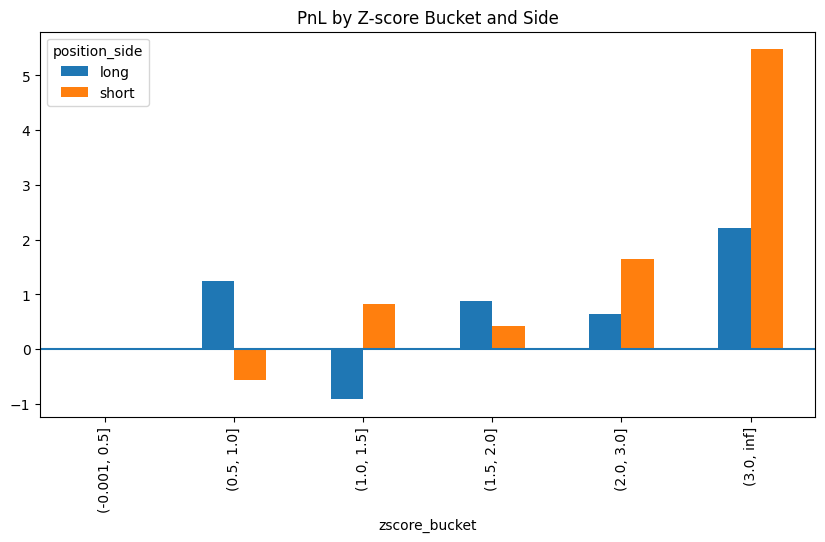

In [143]:
bucket_by_side["avg_pnl_bp"].unstack(0).plot(kind="bar", figsize=(10,5))
plt.title("PnL by Z-score Bucket and Side")
plt.axhline(0)
plt.show()